In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings
sys.path.append("/home/sak0914/MtbQuantCNN")
from cnn_utils import *

import bokeh.io
import bokeh.plotting
import bokeh.models
bokeh.io.output_notebook()

import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150

import sklearn.model_selection
from sklearn.preprocessing import binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc, accuracy_score, balanced_accuracy_score, average_precision_score, confusion_matrix

from Bio import SeqIO
warnings.filterwarnings("ignore")

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")

df_moxi = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/data_for_model.csv")
df_rif = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")

Loading BokehJS ...

FileNotFoundError: [Errno 2] No such file or directory: '/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/data_for_model.csv'

In [ ]:
def plot_init_data(pkl_path, drug):
    
    df = pd.read_pickle(pkl_path)
    
    train = np.log(df.loc[df.category == "original_train_set"][drug + "_midpoint"].values)
    test = np.log(df.loc[df.category == "original_test_set"][drug + "_midpoint"].values)

    p_train = iqplot.ecdf(train, title="Train Set", x_axis_label="Log MIC")
    p_test = iqplot.ecdf(test, title="Test Set", x_axis_label="Log MIC")

    bokeh.io.show(bokeh.layouts.row(p_train, p_test))
    
    # fig_output = pkl_path.split("/")[-1]
    # if not os.path.isdir(os.path.join("Figures", fig_output)):
    #     os.mkdir(os.path.join("Figures", fig_output))
    
    fig, ax = plt.subplots(figsize=(6, 4))
    plt.hist(np.log(df[drug + "_midpoint"].values))
    plt.title(f"{len(df)} Samples")
    plt.xlabel("Log MIC", fontsize=12)
    #plt.savefig(os.path.join("Figures", fig_output, "hist.png"))
    plt.show()

In [ ]:
def compare_distributions(pkl_path, drug):
    
    df = pd.read_pickle(pkl_path)
    
    train = np.log(df.loc[df.category == "original_train_set"][drug + "_midpoint"].values)
    test = np.log(df.loc[df.category == "original_test_set"][drug + "_midpoint"].values)
    
    # fig_output = pkl_path.split("/")[-1]
    # if not os.path.isdir(os.path.join("Figures", fig_output)):
    #     os.mkdir(os.path.join("Figures", fig_output))

    sm.graphics.gofplots.qqplot_2samples(train, test, xlabel="Train Set", ylabel="Test Set", line="45")
    plt.title(f"QQ Plot of {len(df)} Samples")
    #plt.savefig(os.path.join("Figures", fig_output, "qqplot.png"))
    sns.despine()
    plt.show()
    
    print(st.ks_2samp(train, test))

# Replicates Evaluation

Plot validation loss for the 10 bootstrapped replicates and the actual model on top. 

In [4]:
def plot_bootstrap_histories(path, binary=False):
        
    if binary:
        prefix = "binary_"
    else:
        prefix = ""
        
    bootstrap_histories = pd.read_csv(os.path.join(path, f"{prefix}history_replicates.csv"))
    history = pd.read_csv(os.path.join(path, f"{prefix}history.csv"))

    # the history dataframe includes patience epochs. The bootstrap replicates dataframe does not
    num_epochs = len(bootstrap_histories)
    history = history.iloc[:num_epochs, :]
    
    fig, ax = plt.subplots(figsize=(10, 4))

    for i in range(bootstrap_histories.shape[1]):
        plt.plot(bootstrap_histories.index + 1, bootstrap_histories[f"rep_{i+1}"], color="lightgray")

    #plt.plot(bootstrap_histories.index + 1, bootstrap_histories.mean(axis=1), color="red", linewidth=1.5)
    plt.plot(history.index + 1, history["val_loss"], color="red", linewidth=1.5)

    plt.xlabel("Epoch", fontsize=12)
    plot_title = "Validation Loss" + " for " + os.path.basename(path)
    plt.title(plot_title, fontsize=14)
    sns.despine()
    
    #plt.savefig(os.path.join(path, "Figures", "cv_histories.png"))
    plt.show()

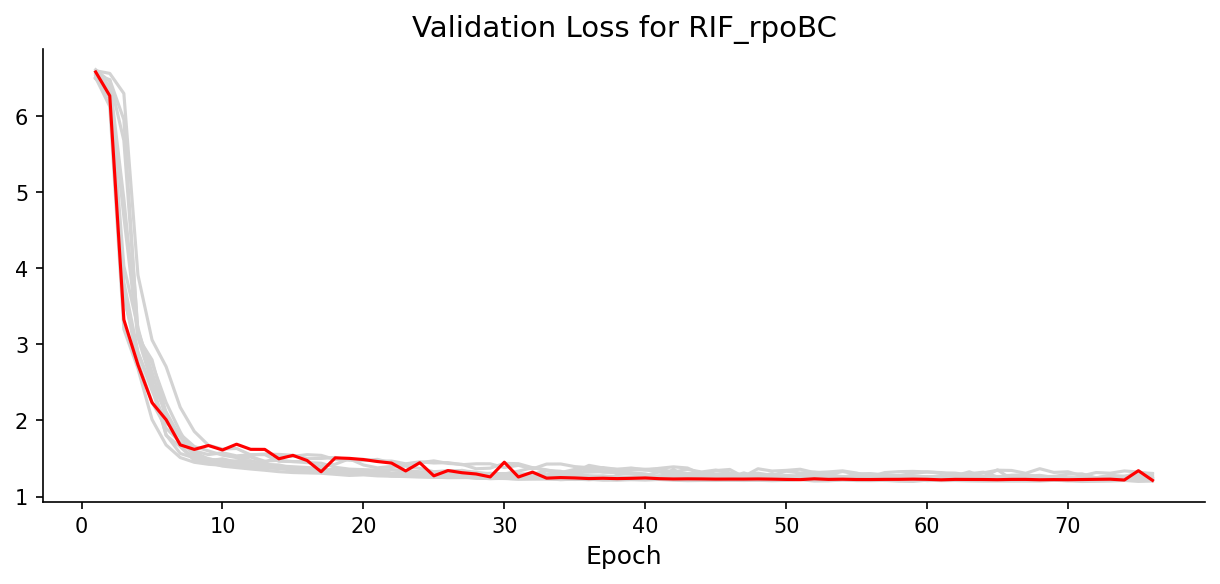

In [5]:
plot_bootstrap_histories(os.path.join(results_path, "RIF_rpoBC"), binary=False)

In [11]:
bootstrap_histories

,rep_1,rep_2,rep_3,rep_4,rep_5,rep_6,rep_7,rep_8,rep_9,rep_10


In [10]:
prefix = "binary_"
bootstrap_histories = pd.read_csv(os.path.join(results_path, "RIF_rpoBC", f"{prefix}history_replicates.csv"))

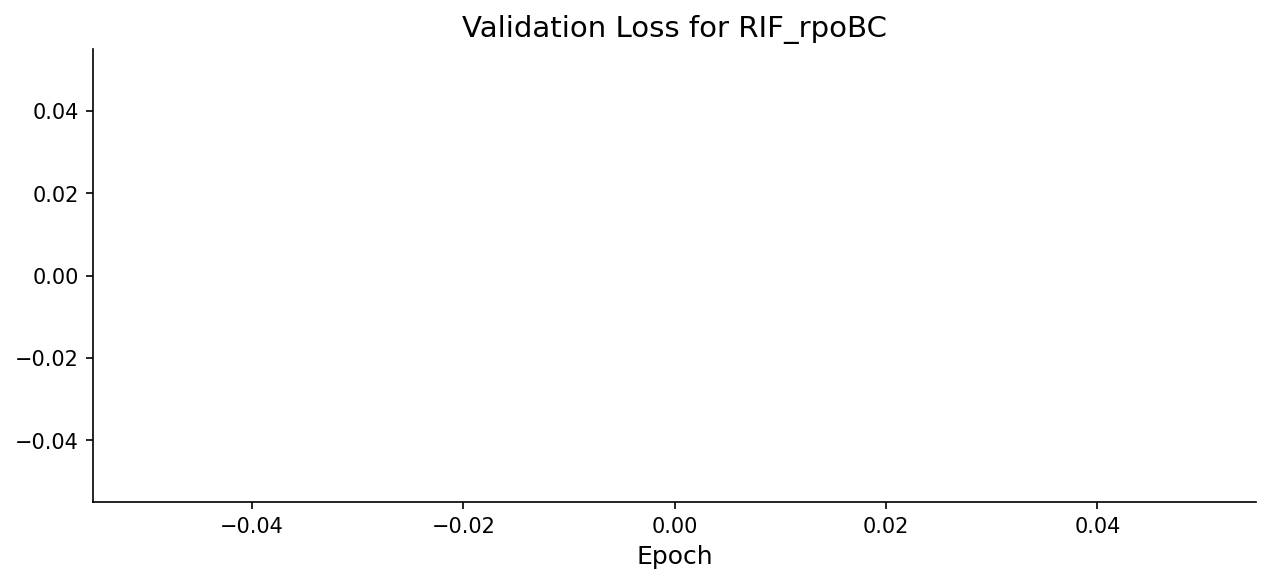

In [6]:
plot_bootstrap_histories(os.path.join(results_path, "RIF_rpoBC"), binary=True)

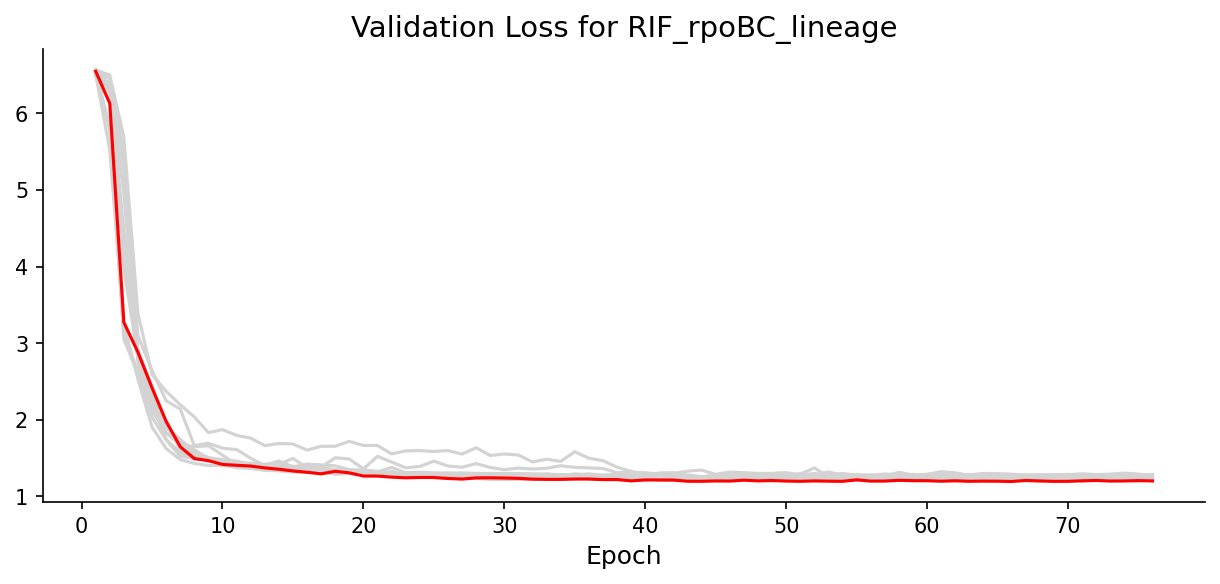

In [7]:
plot_bootstrap_histories(os.path.join(results_path, "RIF_rpoBC_lineage"), binary=False)

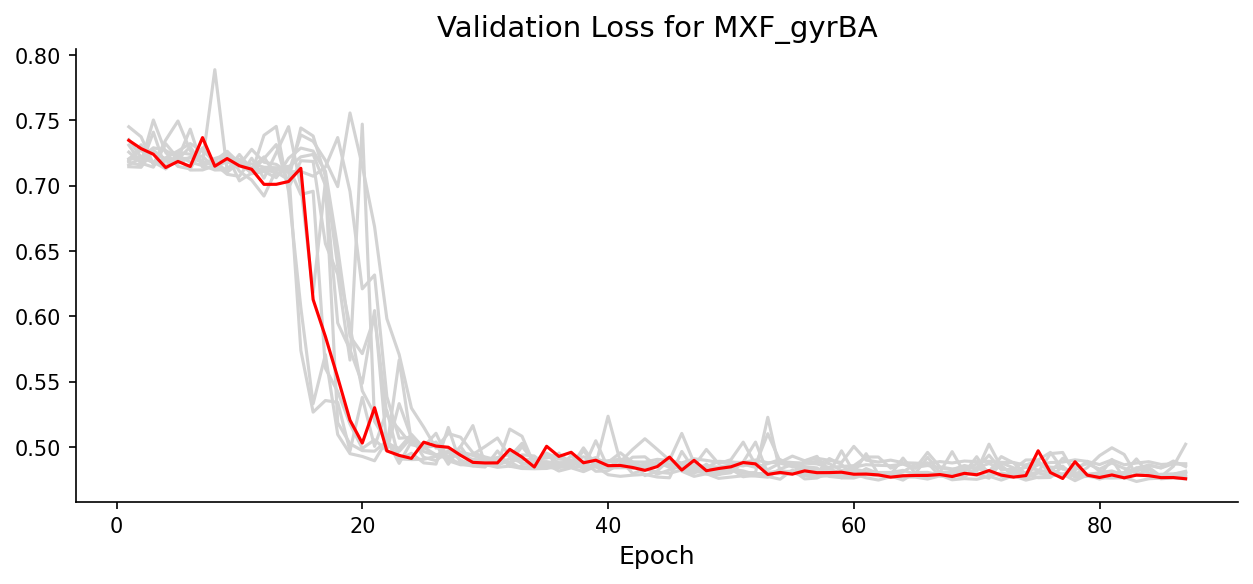

In [97]:
plot_bootstrap_histories(os.path.join(results_path, "MXF_gyrBA"), binary=False)

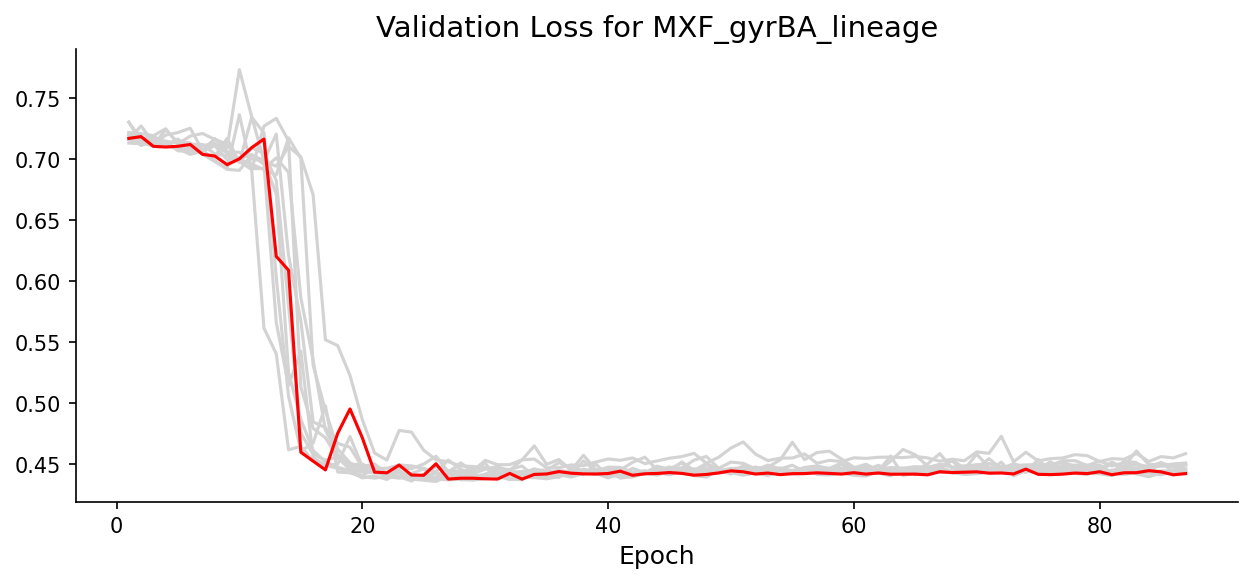

In [98]:
plot_bootstrap_histories(os.path.join(results_path, "MXF_gyrBA_lineage"), binary=False)

In [12]:
def plot_quant_models(df, x_var, quant_var, title, tick_labels, plot_width, legend_loc="upper right", save_title=None):

    if x_var == "Model":
        quant_plot = df.query("CV > 0'").melt(id_vars=["Model"], value_vars=quant_var)
    else:
        quant_plot = df.query("CV > 0").melt(id_vars=["Model", x_var], value_vars=quant_var)
    
    quant_plot["Model"] = quant_plot["Model"].replace("LinReg", "Regression")
    quant_plot["Model"] = quant_plot["Model"].replace("LogReg", "Regression")
        
    palette = sns.color_palette("Set2")
    palette = palette.as_hex()
    color_dict = dict(zip(quant_plot["Model"].unique(), palette[:len(quant_plot["Model"].unique())]))

    fig, ax = plt.subplots(1, 1, figsize=(plot_width, 3.5))
    sns.stripplot(x=x_var, y="value",
                    hue="Model", 
                  dodge=True,
                    data = quant_plot,
                    palette=color_dict,
                  #order=["1", "12"],
                  hue_order=["Regression", "CNN"],
                  linewidth=0.5,
                  ax=ax
                     )



    #plt.ylim(0.5, 0.7)
    ax.get_legend().remove()
    
    legend = plt.legend(loc=legend_loc, fancybox=True, fontsize=8)
    legend.legendHandles[0]._sizes = [20]
    legend.legendHandles[1]._sizes = [20]
    
    plt.title(title)
    plt.xlabel("")
    plt.ylabel(quant_var)
    plt.xticks(ticks=ax.get_xticks(), labels=tick_labels)
    
    sns.despine()
    plt.tight_layout()
    
    if save_title is None:
        plt.show()
    else:
        plt.savefig(save_title, dpi=300)

# Analyze quantitative CNN

In [63]:
def test_for_significance(x1, x2, var, alt="two-sided"):
    
    return st.ttest_rel(x1.query("CV>0")[var], x2.query("CV>0")[var], alternative=alt)[1]
        

def binary_model_analysis(path, drug, cc, num_loci, lineage=0, cv=True, plot=True, patience=25):
    
    history = pd.read_csv(os.path.join(path, "binary_history.csv"))
    pred = pd.read_csv(os.path.join(path, "binary_test_predictions.csv"))
    
    if patience != 0:
        history = history.iloc[:-patience, :]

    print(f"{len(pred)} points in validation set")
    print(f"Trained CNN for {len(history)} epochs")
    
    if plot:
        fig, ax = plt.subplots(figsize=(4, 2))

        plt.plot(history.index+1, history["val_loss"], label="Loss")
        plt.title("Validation Loss", fontsize=14)
        #plt.xlim(0, stop_epoch)

        sns.despine()
        plt.xlabel("Epoch", fontsize=10)
    
    summary_df = pd.DataFrame({"Drug": drug,
                               "Model": "CNN",
                               "Num_Loci": num_loci,
                              }, index=[0])
    
    summary_df["Num_Loci"] = "Binary"
    summary_df["CV"] = 0
    summary_df["Lineage"] = lineage
    summary_metrics_df = compute_binary_metrics(pred.y_pred_label, pred.y_test, cc, binarize=False)
    summary_df = pd.concat([summary_df, summary_metrics_df], axis=1)
    
    if cv:
        cv_results = pd.read_csv(os.path.join(path, "binary_val_results.csv"))
        cv_results["CV"] = np.arange(len(cv_results))+1
        cv_results["Num_Loci"] = "Binary"
        cv_results["Lineage"] = lineage
        return pd.concat([summary_df, cv_results])
    else:
        return summary_df
    

def quant_model_analysis(path, drug, cc, df_phenos, num_loci, lineage=0, cv=True, plot=True, patience=25):
    
    pred_df = pd.read_csv(os.path.join(path, "test_predictions.csv"))
    history = pd.read_csv(os.path.join(path, "history.csv"))
    
    if patience != 0:
        history = history.iloc[:-patience, :]
    
    print(f"{len(pred_df)} points in validation set")
    print(f"Trained CNN for {len(history)} epochs")
    
    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))

        ax[0].plot(history.index+1, history["val_loss"], label="Loss")
        ax[0].set_title("Validation Loss", fontsize=14)
        ax[0].set_xlabel("Epoch", fontsize=10)
        
        values = np.vstack([pred_df["y_pred"], pred_df["y_test"]])
        kernel = st.gaussian_kde(values)(values)

        sns.scatterplot(
            data=pred_df,
            x="y_pred",
            y="y_test",
            c=kernel,
            cmap="Blues",
            linewidth=0.25,
            edgecolor="lightgray",
            ax=ax[1]
        )

        max_val = np.max([pred_df.y_pred, pred_df.y_test]) * 1.1
        min_val = np.min([pred_df.y_pred, pred_df.y_test]) * 1.1

        ax[1].set_xlabel("Predicted log(MIC)")
        ax[1].set_ylabel("Actual log(MIC)")
        ax[1].set_xlim(min_val, max_val)
        ax[1].set_ylim(min_val, max_val)

        sns.despine()
        plt.show()
        
    binned_mae, binned_mse, within_1bin = boundedLoss_predict(pred_df, "y_pred", "y_test", "lower", "upper")
    mae = np.mean(np.abs(pred_df.y_pred - pred_df.y_test))
    mse = np.mean((pred_df.y_pred - pred_df.y_test)**2)
    
    summary_df = pd.DataFrame({"Drug": drug,
                               "Model": "CNN",
                               "Num_Loci": num_loci,
                               "Binned_MAE": binned_mae,
                               "Binned_MSE": binned_mse,
                               "MAE": mae,
                               "MSE": mse,
                               "Within_1bin": within_1bin,
                               "Pearson": st.pearsonr(pred_df.y_pred, pred_df.y_test)[0],
                               "Lineage": lineage,
                               "CV": 0
                              }, index=[0])
    
    binary_metrics_df = compute_binary_metrics(pred_df.y_test, pred_df.y_pred, cc, binarize=True)
    summary_df = pd.concat([summary_df, binary_metrics_df], axis=1)
    
    if cv:
        cv_results = pd.read_csv(os.path.join(path, "val_results.csv"))
        cv_results["CV"] = np.arange(len(cv_results))+1
        cv_results["Num_Loci"] = num_loci
        cv_results["Lineage"] = lineage
        return pd.concat([summary_df, cv_results])
    else:
        return summary_df

# Rifampicin

In [82]:
rif_rpoBC_CNN = quant_model_analysis(os.path.join(results_path, "RIF_rpoBC"), "RIF", 0.5, df_rif, 1, lineage=0, patience=25, cv=True, plot=False)
rif_rpoBC_LinReg = pd.read_csv(os.path.join(results_path, "RIF_rpoBC", "ridge", "ridge_results.csv"))

rif_rpoBC_lineage_CNN = quant_model_analysis(os.path.join(results_path, "RIF_rpoBC_lineage"), "RIF", 0.5, df_rif, 1, lineage=1, patience=0, cv=True, plot=False)
rif_rpoBC_lineage_LinReg = pd.read_csv(os.path.join(results_path, "RIF_rpoBC_lineage", "ridge", "ridge_results.csv"))

rif_rpoBC_binary_CNN = binary_model_analysis(os.path.join(results_path, "RIF_rpoBC"), "RIF", 0.5, 1, lineage=0, cv=True, plot=False)
rif_rpoBC_binary_LogReg = pd.read_csv(os.path.join(results_path, "RIF_rpoBC", "ridge", "binary_ridge_results.csv"))

1871 points in validation set
Trained CNN for 76 epochs
1871 points in validation set
Trained CNN for 76 epochs
1871 points in validation set
Trained CNN for 80 epochs


In [83]:
# - lineage CNN is better than - lineage linReg
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    if "MAE" in var or "MSE" in var:
        print(var, test_for_significance(rif_rpoBC_CNN, rif_rpoBC_LinReg, var, alt="less"))
    else:
        print(var, test_for_significance(rif_rpoBC_CNN, rif_rpoBC_LinReg, var, alt="greater"))

Binned_MAE 0.00017406887453375364
MAE 3.378001838564246e-05
Binned_MSE 7.429378137656157e-09
MSE 1.5305648003553254e-07
Pearson 1.4596134331657272e-09
Within_1bin 0.004169003960384687


In [65]:
# + / lineage linReg: NO DIFFERENCEs
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    print(var, test_for_significance(rif_rpoBC_LinReg, rif_rpoBC_lineage_LinReg, var, alt="two-sided"))

Binned_MAE 0.25075239753015616
MAE 0.11940808713659484
Binned_MSE 0.36333006391453737
MSE 0.3822603042549255
Pearson 0.40710406029733925
Within_1bin 0.11865604848380841


In [66]:
# Pearson R is significantly higher for lineage CNN
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    print(var, test_for_significance(rif_rpoBC_CNN, rif_rpoBC_lineage_CNN, var, alt="two-sided"))

Binned_MAE 0.18464722653735782
MAE 0.19781003997545688
Binned_MSE 0.3705579897095066
MSE 0.7097215721530326
Pearson 0.5113064638687205
Within_1bin 0.07677309854840098


In [67]:
# Pearson R is significantly higher for lineage CNN
for var in ["Sensitivity", "Specificity", "AUC", "Balanced_Acc"]:
    print(var, test_for_significance(rif_rpoBC_CNN, rif_rpoBC_binary_CNN, var, alt="two-sided"))

Sensitivity 0.06121108365801539
Specificity 0.8226545408271811
AUC 0.02827780590331512
Balanced_Acc 0.028277805903313285


In [68]:
st.ttest_rel(rif_rpoBC_binary_CNN.query("CV > 0")["AUC"], rif_rpoBC_CNN.query("CV > 0")["AUC"], 
             alternative="two-sided"
            )

Ttest_relResult(statistic=2.6098479706781013, pvalue=0.02827780590331512)

In [75]:
rif_rpoBC_quant_compare = pd.concat([rif_rpoBC_CNN, rif_rpoBC_LinReg, rif_rpoBC_lineage_CNN, rif_rpoBC_lineage_LinReg], axis=0)
rif_rpoBC_quant_compare["Group"] = [1]*22 + [2]*22

rif_rpoBC_binary_CNN["Drug"] = "RIF"
rif_rpoBC_binary_CNN["Model"] = "CNN"

rif_rpoBC_binary_compare = pd.concat([rif_rpoBC_binary_CNN, rif_rpoBC_binary_LogReg,
                                      rif_rpoBC_CNN, rif_rpoBC_LinReg, rif_rpoBC_lineage_CNN, rif_rpoBC_lineage_LinReg], axis=0)
rif_rpoBC_binary_compare["Group"] = [1]*22 + [2]*22 + [3]*22

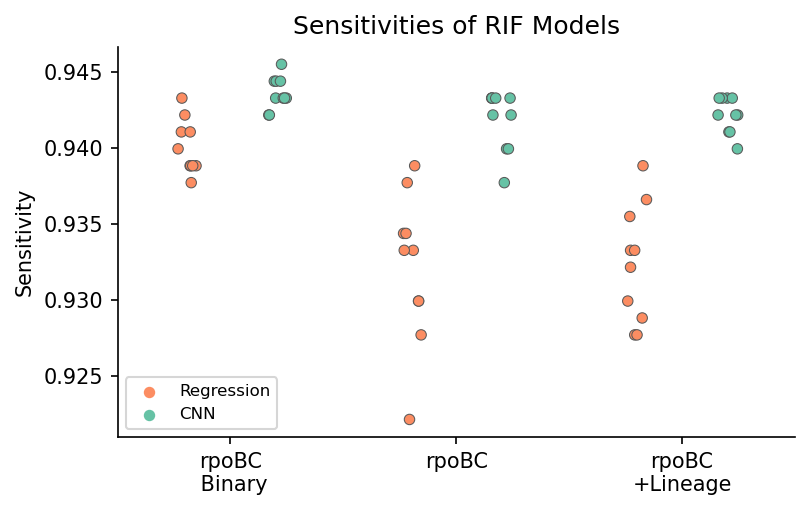

In [81]:
plot_quant_models(rif_rpoBC_binary_compare, "Group", "Sensitivity", "Sensitivities of RIF Models", 
                  tick_labels=["rpoBC\n Binary", "rpoBC", "rpoBC\n+Lineage"], plot_width=5.5, legend_loc="lower left")

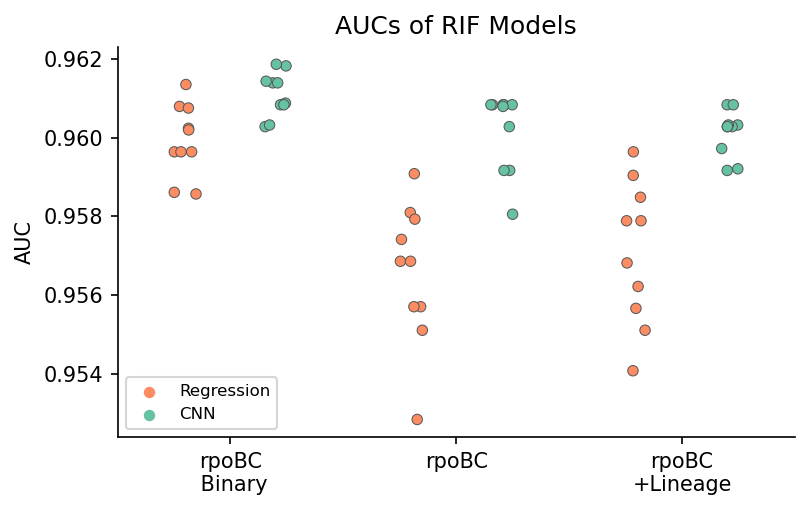

In [79]:
plot_quant_models(rif_rpoBC_binary_compare, "Group", "AUC", "AUCs of RIF Models", 
                  tick_labels=["rpoBC\n Binary", "rpoBC", "rpoBC\n+Lineage"], plot_width=5.5, legend_loc="lower left")

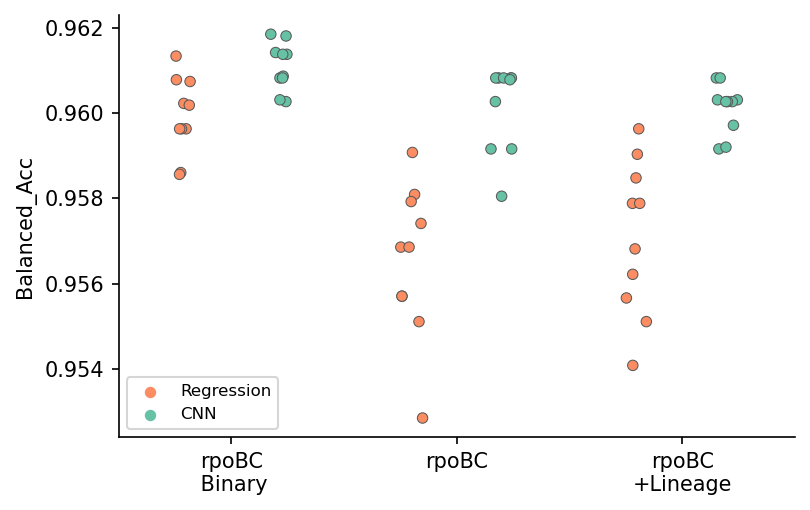

In [80]:
plot_quant_models(rif_rpoBC_binary_compare, "Group", "Balanced_Acc", "", 
                  tick_labels=["rpoBC\n Binary", "rpoBC", "rpoBC\n+Lineage"], plot_width=5.5, legend_loc="lower left")

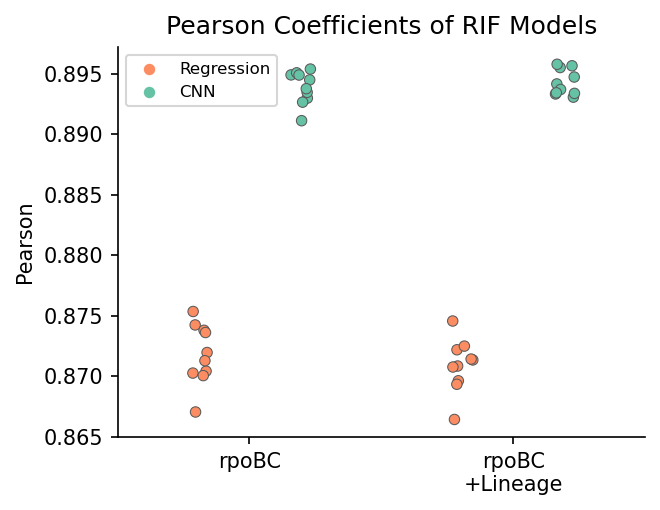

In [27]:
plot_quant_models(rif_rpoBC_quant_compare, "Group", "Pearson", "Pearson Coefficients of RIF Models", 
                  tick_labels=["rpoBC", "rpoBC\n+Lineage"], plot_width=4.5, legend_loc="upper left"
                  #save_title="../Figures/rif_4Model_comparison.png"
                 )

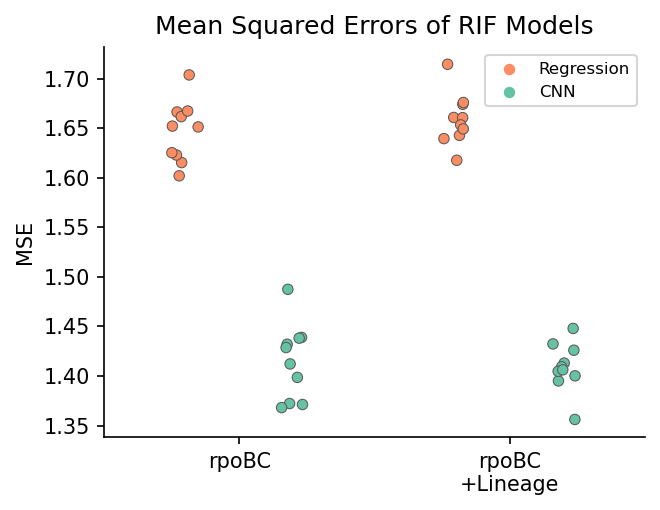

In [29]:
plot_quant_models(rif_rpoBC_quant_compare, "Group", "MSE", "Mean Squared Errors of RIF Models", 
                  tick_labels=["rpoBC", "rpoBC\n+Lineage"], plot_width=4.5,
                  #save_title="../Figures/rif_4Model_comparison.png"
                 )

# Moxifloxacin

In [86]:
moxi_gyrBA_CNN = quant_model_analysis(os.path.join(results_path, "MOXI_gyrBA"), "MOXI", 0.5, df_moxi, 1, lineage=0, patience=25, cv=True, plot=False)
moxi_gyrBA_LinReg = pd.read_csv(os.path.join(results_path, "MOXI_gyrBA", "ridge", "ridge_results.csv"))

moxi_gyrBA_lineage_CNN = quant_model_analysis(os.path.join(results_path, "MOXI_gyrBA_lineage"), "MOXI", 0.5, df_moxi, 1, lineage=1, patience=0, cv=True, plot=False)
moxi_gyrBA_lineage_LinReg = pd.read_csv(os.path.join(results_path, "MOXI_gyrBA_lineage", "ridge", "ridge_results.csv"))

moxi_5Loci_CNN = quant_model_analysis(os.path.join(results_path, "MOXI_5Loci"), "MOXI", 0.5, df_moxi, 1, lineage=0, patience=25, cv=True, plot=False)
moxi_5Loci_LinReg = pd.read_csv(os.path.join(results_path, "MOXI_5Loci", "ridge", "ridge_results.csv"))



1460 points in validation set
Trained CNN for 87 epochs
1460 points in validation set
Trained CNN for 87 epochs
1460 points in validation set
Trained CNN for 62 epochs


In [89]:
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    if "MAE" in var or "MSE" in var:
        print(var, test_for_significance(moxi_gyrBA_CNN, moxi_gyrBA_LinReg, var, alt="less"))
    else:
        print(var, test_for_significance(moxi_gyrBA_CNN, moxi_gyrBA_LinReg, var, alt="greater"))

Binned_MAE 0.005633747652150694
MAE 2.7341553998314277e-06
Binned_MSE 0.0008890106737611572
MSE 0.0005009033601741241
Pearson 8.896327323512899e-07
Within_1bin 8.22860127848929e-06


In [90]:
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    if "MAE" in var or "MSE" in var:
        print(var, test_for_significance(moxi_gyrBA_lineage_CNN, moxi_gyrBA_CNN, var, alt="less"))
    else:
        print(var, test_for_significance(moxi_gyrBA_lineage_CNN, moxi_gyrBA_CNN, var, alt="greater"))

Binned_MAE 9.86880983892686e-09
MAE 4.6889270831905496e-07
Binned_MSE 7.623684656136193e-08
MSE 1.4350063993298556e-07
Pearson 4.252528739604639e-10
Within_1bin 3.4581906890138404e-10


In [91]:
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    if "MAE" in var or "MSE" in var:
        print(var, test_for_significance(moxi_gyrBA_lineage_CNN, moxi_gyrBA_lineage_LinReg, var, alt="less"))
    else:
        print(var, test_for_significance(moxi_gyrBA_lineage_CNN, moxi_gyrBA_lineage_LinReg, var, alt="greater"))

Binned_MAE 0.0021124306970952775
MAE 5.825711131134603e-09
Binned_MSE 0.0027882618892869837
MSE 3.088542270067074e-05
Pearson 2.0886843326740607e-06
Within_1bin 7.605427419780961e-10


In [93]:
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    if "MAE" in var or "MSE" in var:
        print(var, test_for_significance(moxi_5Loci_CNN, moxi_gyrBA_CNN, var, alt="less"))
    else:
        print(var, test_for_significance(moxi_5Loci_CNN, moxi_gyrBA_CNN, var, alt="greater"))

Binned_MAE 3.425449087819467e-07
MAE 5.12399003036807e-06
Binned_MSE 3.0865917279610517e-07
MSE 2.954196536965786e-07
Pearson 1.5325825973935236e-10
Within_1bin 7.46274162130827e-05


In [92]:
for var in ["Binned_MAE", "MAE", "Binned_MSE", "MSE", "Pearson", "Within_1bin"]:
    print(var, test_for_significance(moxi_5Loci_CNN, moxi_gyrBA_lineage_CNN, var, alt="two-sided"))

Binned_MAE 8.735226470869224e-06
MAE 0.10302156496288939
Binned_MSE 0.0005812148384830961
MSE 0.0007103966646434194
Pearson 7.452900988409072e-05
Within_1bin 0.2658251282147448


In [94]:
moxi_to_compare = pd.concat([moxi_gyrBA_CNN, moxi_gyrBA_LinReg, 
                             moxi_gyrBA_lineage_CNN, moxi_gyrBA_lineage_LinReg,
                             moxi_5Loci_CNN, moxi_5Loci_LinReg
                            ], axis=0)
moxi_to_compare["Group"] = [1]*22 + [2]*22 + [3]*22

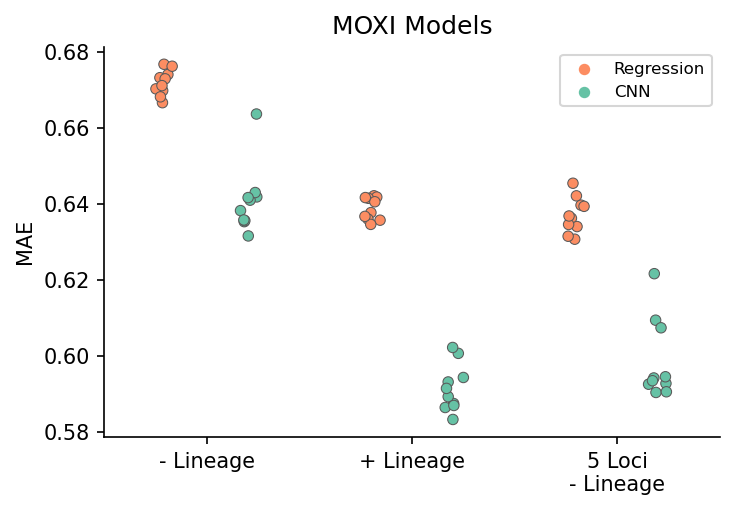

In [95]:
plot_quant_models(moxi_to_compare, "Group", "MAE", "MOXI Models", 
                  ["- Lineage", "+ Lineage", "5 Loci\n- Lineage"],
                  5, 
                  #save_title="../Figures/moxi_lineage_comparison.png"
                 )

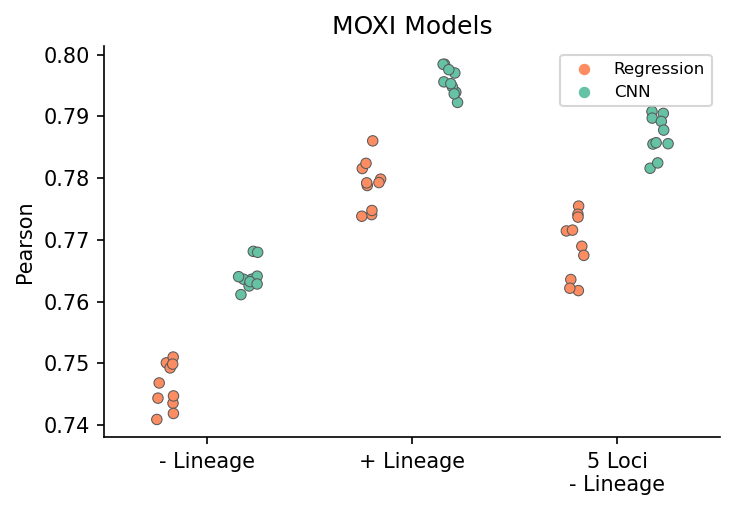

In [45]:
plot_quant_models(moxi_to_compare, "Group", "Pearson", "MOXI Models", 
                  ["- Lineage", "+ Lineage", "5 Loci\n- Lineage"],
                  5, 
                  #save_title="../Figures/moxi_lineage_comparison.png"
                 )

# Which Genes Contributed Most to Performance Gains?

In [25]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 
              'Rv2836c_Rv2837c', 
              'Rv3361c_Rv3365c', 'Rv0014c_Rv0015c', 'arfABC', 'phoPR', 'mbtK', 'Rv3561_Rv3565', 'stp', 
              'Rv0053_Rv0058', 'ligD_Rv0939'][1:]

In [26]:
dfs_lst = []
for locus in locus_list:
    df = quant_model_analysis(os.path.join(results_path, f"20220912_moxi_gyrBA_{locus}"), "MOXI", 0.5, df_moxi, 2, bs=True, plot=False)
    df["Gene"] = locus
    dfs_lst.append(df)
    
df_add_loci = pd.concat(dfs_lst)

1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs
1442 points in validation set
Trained CNN for 462 epochs


In [27]:
#moxi_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/isolate_variants.csv")

In [28]:
# # check the sequence quality for candidate loci
# genotype_input_directory = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas"
# locus_list = ['gyrBA', 'Rv3561_Rv3565', 'Rv0981_Rv0984', 'Rv3361c_Rv3365c'] 

# for locus in locus_list:
#     with open(os.path.join(genotype_input_directory, locus + ".sh"), "r") as file:
#         lines = file.readlines()
        
#         start, end = lines[-1].split("-")
#         start = int(start.split(" ")[-1])
#         end = int(end.split(" ")[0])
#         single_locus = moxi_isolate_variants.query("POS >= @start & POS <= @end")
#         print(f"{locus}:", single_locus.QC.value_counts(dropna=False)[1] / len(single_locus))

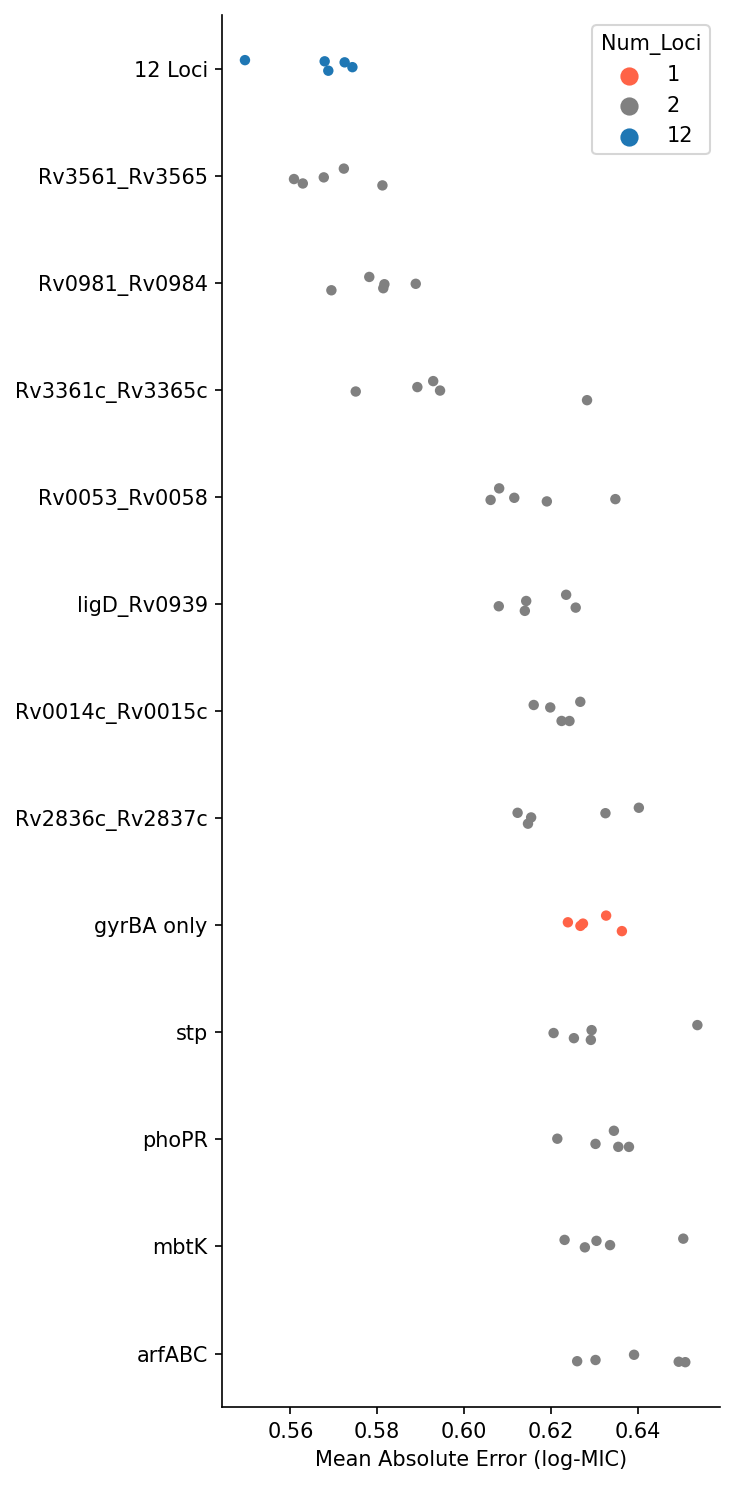

In [32]:
df_plot = pd.concat([df_add_loci.query("CV>0"), 
                     moxi_gyrBA.query("CV>0"), 
                     moxi_12Loci.query("CV>0")
                    ]).reset_index(drop=True)

df_plot.loc[df_plot["Num_Loci"] == 1, "Gene"] = "gyrBA only"
df_plot.loc[df_plot["Num_Loci"] == 12, "Gene"] = "12 Loci"
df_plot["Num_Loci"] = df_plot["Num_Loci"].astype(int)

# order by increasing mean
plot_order = df_plot.groupby("Gene")["MAE"].mean().sort_values().index.values

palette = {
    2: 'gray',
    12: '#1f77b4',
    1: 'tomato',
}

fig, ax = plt.subplots(1, 1, figsize=(5, 10))
sns.stripplot(data=df_plot, y="Gene", x="MAE", hue="Num_Loci", order=plot_order, palette=palette, dodge=False, ax=ax)
plt.xlabel("Mean Absolute Error (log-MIC)")
plt.ylabel("")
#plt.xticks(rotation=90)
sns.despine()
#plt.show()
plt.tight_layout()
plt.savefig("../Figures/moxi_12Loci_pairwise.png", dpi=300)

In [26]:
# df_plot = pd.concat([df_add_loci.query("CV==0"), 
#                      moxi_gyrBA.query("CV==0"), 
#                      moxi_12Loci.query("CV==0")
#                     ]).reset_index(drop=True)

# df_plot.loc[df_plot["Num_Loci"] == 1, "Gene"] = "gyrBA only"
# df_plot.loc[df_plot["Num_Loci"] == 12, "Gene"] = "12 Loci"
# df_plot["Num_Loci"] = df_plot["Num_Loci"].astype(int)

# # order by increasing mean
# plot_order = df_plot.groupby("Gene")["MAE"].mean().sort_values().index.values

# palette = {
#     2: 'gray',
#     12: '#1f77b4',
#     1: 'tomato',
# }

# fig, ax = plt.subplots(1, 1, figsize=(4, 10))
# sns.barplot(data=df_plot, y="Gene", x="MAE", hue="Num_Loci", order=plot_order, palette=palette, dodge=False, ax=ax)
# plt.xlabel("Mean Absolute Error (log-MIC)")
# plt.ylabel("")
# #plt.xticks(rotation=90)
# sns.despine()
# plt.show()

# Differences between single- and 12-Loci Models

## 1. Get predictions on full dataset, not just the testing dataset

In [43]:
def get_model_predictions(output_path, df_phenos):
    
    model = load_model(os.path.join(output_path, 'best_model.h5'))
    phenotype_file = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv"
    drug = "MOXI"
    locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv2836c_Rv2837c', 'Rv3361c_Rv3365c', 'Rv0014c_Rv0015c', 'arfABC', 'phoPR', 'mbtK', 'Rv3561_Rv3565', 'stp', 'Rv0053_Rv0058', 'ligD_Rv0939']
    BATCH_SIZE = 128
    binary_thresh = 0.05
    
    train_generator = MtbGeneDataset(
                        os.path.join(output_path, 'pkl_sparse_train.npz'),
                        phenotype_file,
                        drug,
                        locus_list,
                        train_or_test="original_train_set",
                        binary=False,
                        cc=binary_thresh,
                        data_idx=None,
                        batch_size=BATCH_SIZE,
                        shuffle=True
                        )

    val_generator = MtbGeneDataset(
                        os.path.join(output_path, 'pkl_sparse_test.npz'),
                        phenotype_file,
                        drug,
                        locus_list,
                        train_or_test="original_test_set",
                        binary=False,
                        cc=binary_thresh,
                        data_idx=None,
                        batch_size=BATCH_SIZE,
                        shuffle=False
                    )
    
    # get model predictions
    y_pred_train = model.predict(
        x=train_generator,
        workers=4,
        use_multiprocessing=True,
    )
    
    y_pred_val = model.predict(
        x=val_generator,
        workers=4,
        use_multiprocessing=True,
    )

    # get test values and IDs from the dataset class
    ids_train = np.array([])
    ids_val = np.array([])
    y_test_train = np.array([])
    y_test_val = np.array([])
    
    for i, _ in enumerate(train_generator):

        batch = train_generator.__getTestData__(i)

        ids_train = np.concatenate([ids_train, batch[0]])
        y_test_train = np.concatenate([y_test_train, batch[1]])

    for i, _ in enumerate(val_generator):

        batch = val_generator.__getTestData__(i)

        ids_val = np.concatenate([ids_val, batch[0]])
        y_test_val = np.concatenate([y_test_val, batch[1]])
        
    pred_df = pd.DataFrame({"Isolate": np.concatenate([ids_train, ids_val]), 
                            "y_pred": np.concatenate([np.squeeze(y_pred_train), np.squeeze(y_pred_val)]),
                            "y_test": np.concatenate([y_test_train, y_test_val]),
                            "category": ["original_train_set"]*len(ids_train) + ["original_test_set"]*len(ids_val)
                           })
    
    return pred_df.merge(df_phenos[["ROLLINGDB_ID", "category"]], left_on="Isolate", right_on="ROLLINGDB_ID")

In [44]:
gyrBA_pred = get_model_predictions(os.path.join(results_path, "20220902_moxi_gyrBA"), df_moxi)
multiLoci_pred = get_model_predictions(os.path.join(results_path, "20220907_moxi_12Loci"), df_moxi)

12 loci, longest locus: 4831, 5767 isolates
12 loci, longest locus: 4831, 1442 isolates
12/12 [==============================] - 39s 3s/step
12 loci, longest locus: 5822, 5767 isolates
12 loci, longest locus: 5822, 1442 isolates
12/12 [==============================] - 135s 9s/step


In [6]:
gyrBA_pred["y_binary_gyrBA_pred"] = (gyrBA_pred.y_pred > np.log(0.5)).astype(int)
gyrBA_pred["y_binary_test"] = (gyrBA_pred.y_test > np.log(0.5)).astype(int)

multiLoci_pred["y_binary_multiLoci_pred"] = (multiLoci_pred.y_pred > np.log(0.5)).astype(int)

gyrBA_pred.rename(columns={"y_pred": "y_gyrBA_pred"}, inplace=True)
multiLoci_pred.rename(columns={"y_pred": "y_multiLoci_pred"}, inplace=True)

pred_analysis = gyrBA_pred.merge(multiLoci_pred[["Isolate", "y_multiLoci_pred", "y_binary_multiLoci_pred"]], on="Isolate")

# absolute error
pred_analysis["error_multiLoci"] = pred_analysis["y_multiLoci_pred"] - pred_analysis["y_test"]
pred_analysis["error_gyrBA"] = pred_analysis["y_gyrBA_pred"] - pred_analysis["y_test"]

In [58]:
pred_analysis.query("category == 'original_test_set' & (error_multiLoci > 1 | error_multiLoci < -1 | error_gyrBA > 1 | error_gyrBA < -1)")

,Isolate,y_gyrBA_pred,y_test,ROLLINGDB_ID,category,y_binary_gyrBA_pred,y_binary_test,y_multiLoci_pred,y_binary_multiLoci_pred,error_multiLoci,error_gyrBA
5785,ERR4810964,-0.835585,-0.980829,ERR4810964,original_test_set,0,0,-2.459857,0,-1.479028,0.145244
5815,ERR4810574,-2.411800,-0.980829,ERR4810574,original_test_set,0,0,-3.142566,0,-2.161737,-1.430971
5824,ERR4810595,-2.427772,-0.980829,ERR4810595,original_test_set,0,0,-2.400660,0,-1.419831,-1.446942
5827,ERR4811106,-2.427772,-0.287682,ERR4811106,original_test_set,0,1,-2.434706,0,-2.147024,-2.140089
5846,ERR4810708,-2.427772,-0.980829,ERR4810708,original_test_set,0,0,-2.437555,0,-1.456726,-1.446942
...,...,...,...,...,...,...,...,...,...,...,...
7203,SAMN02398716,0.721246,1.791759,SAMN02398716,original_test_set,1,1,1.943485,1,0.151725,-1.070514
7204,SAMN02360610,-0.146260,1.791759,SAMN02360610,original_test_set,1,1,1.762516,1,-0.029243,-1.938020
7205,SAMN02360612,-2.427772,-0.980829,SAMN02360612,original_test_set,0,0,-2.463201,0,-1.482371,-1.446942
7206,SAMN02360566,1.039651,2.484907,SAMN02360566,original_test_set,1,1,2.001313,1,-0.483594,-1.445256


In [65]:
pred_analysis.query("(error_multiLoci > 1 | error_multiLoci < -1)")

,Isolate,y_gyrBA_pred,y_test,ROLLINGDB_ID,category,y_binary_gyrBA_pred,y_binary_test,y_multiLoci_pred,y_binary_multiLoci_pred,error_multiLoci,error_gyrBA
0,ERR4813292,-2.347197,-4.199705,ERR4813292,original_train_set,0,0,-2.395365,0,1.804340,1.852508
3,ERR3287863,-2.427772,1.098612,ERR3287863,original_train_set,0,1,-2.463201,0,-3.561813,-3.526384
5,ERR4810943,-2.385815,-0.287682,ERR4810943,original_train_set,0,1,-2.445794,0,-2.158112,-2.098133
7,ERR4831292,-2.373073,-4.199705,ERR4831292,original_train_set,0,0,-0.230749,1,3.968956,1.826632
14,ERR2184533,-2.427772,-2.407946,ERR2184533,original_train_set,0,0,-0.218629,1,2.189316,-0.019826
...,...,...,...,...,...,...,...,...,...,...,...
7195,SAMN02381011,-2.427772,-1.687399,SAMN02381011,original_test_set,0,0,-2.745936,0,-1.058537,-0.740372
7196,SAMN02381022,-1.129277,-2.407946,SAMN02381022,original_test_set,0,0,-1.350594,0,1.057351,1.278669
7197,SAMN02364078,0.721246,2.484907,SAMN02364078,original_test_set,1,1,0.805003,1,-1.679904,-1.763661
7200,SAMN02381027,1.125515,2.484907,SAMN02381027,original_test_set,1,1,1.216023,1,-1.268883,-1.359392


In [66]:
pred_analysis.query("(error_gyrBA > 1 | error_gyrBA < -1)")

,Isolate,y_gyrBA_pred,y_test,ROLLINGDB_ID,category,y_binary_gyrBA_pred,y_binary_test,y_multiLoci_pred,y_binary_multiLoci_pred,error_multiLoci,error_gyrBA
0,ERR4813292,-2.347197,-4.199705,ERR4813292,original_train_set,0,0,-2.395365,0,1.804340,1.852508
3,ERR3287863,-2.427772,1.098612,ERR3287863,original_train_set,0,1,-2.463201,0,-3.561813,-3.526384
5,ERR4810943,-2.385815,-0.287682,ERR4810943,original_train_set,0,1,-2.445794,0,-2.158112,-2.098133
7,ERR4831292,-2.373073,-4.199705,ERR4831292,original_train_set,0,0,-0.230749,1,3.968956,1.826632
13,ERR4830370,0.721246,-4.199705,ERR4830370,original_train_set,1,0,-3.907146,0,0.292560,4.920951
...,...,...,...,...,...,...,...,...,...,...,...
7203,SAMN02398716,0.721246,1.791759,SAMN02398716,original_test_set,1,1,1.943485,1,0.151725,-1.070514
7204,SAMN02360610,-0.146260,1.791759,SAMN02360610,original_test_set,1,1,1.762516,1,-0.029243,-1.938020
7205,SAMN02360612,-2.427772,-0.980829,SAMN02360612,original_test_set,0,0,-2.463201,0,-1.482371,-1.446942
7206,SAMN02360566,1.039651,2.484907,SAMN02360566,original_test_set,1,1,2.001313,1,-0.483594,-1.445256


In [7]:
np.mean(np.abs(pred_analysis["error_multiLoci"])), np.mean(np.abs(pred_analysis["error_gyrBA"]))

(1.2430196345954958, 1.1773506976735264)

In [8]:
np.mean(pred_analysis["error_multiLoci"]), np.mean(pred_analysis["error_gyrBA"])

(0.010255394398853437, 0.11432793514668267)

In [45]:
# residuals = pred_analysis[["Isolate", "error_multiLoci", "error_gyrBA"]].melt(id_vars="Isolate")
# residuals["y_test"] = residuals["Isolate"].map(dict(zip(pred_analysis["Isolate"], pred_analysis["y_test"])))
# residuals["group"] = np.round(np.exp(residuals["y_test"]), decimals=2).astype(str)
# #residuals["abs_error"] = np.abs(residuals["value"])

# fig, ax = plt.subplots(1, 1, figsize=(10, 6))
# sns.stripplot(data=residuals, x="group", y="value", hue="variable", jitter=True, dodge=True, 
#               order=np.sort(np.unique(residuals["group"].astype(float))).astype(str),
#               ax=ax
#              )
# plt.ylim(-residuals.value.abs().max()*1.1, residuals.value.abs().max()*1.1)
# plt.axhline(y=0, xmin=residuals.y_test.min(), xmax=residuals.y_test.max(), linewidth=0.5, color="black")
# sns.despine()
# plt.show()

# # df = residuals.query("variable == 'error_gyrBA'")
# # sns.scatterplot(data=df, x="y_test", y="value")
# # plt.ylim(-df.value.abs().max()*1.1, df.value.abs().max()*1.1)
# # plt.axhline(y=0, xmin=df.y_test.min(), xmax=df.y_test.max(), linewidth=0.5, color="black")
# # sns.despine()
# # plt.show()

In [19]:
# predicted wrong by both models --> run LASSO + Ridge on this
#df_moxi.query('ROLLINGDB_ID in @pred_analysis.query("y_binary_gyrBA_pred != y_binary_test & y_binary_multiLoci_pred != y_binary_test").Isolate.values').to_csv("phenos_mispredict_isolates.csv", index=False)
pred_analysis.query("y_binary_gyrBA_pred != y_binary_test & y_binary_multiLoci_pred != y_binary_test").shape


(850, 11)

In [28]:
# when both were wrong, multiLoci model underestimates to a greater degree than gyrBA-only model. The difference is significant
pred_analysis.query("y_binary_gyrBA_pred != y_binary_test & y_binary_multiLoci_pred != y_binary_test")[["error_multiLoci", "error_gyrBA"]].mean()

error_multiLoci   -2.103691
error_gyrBA       -2.043861
dtype: float64

In [38]:
st.ttest_rel(pred_analysis.query("y_binary_gyrBA_pred != y_binary_test & y_binary_multiLoci_pred != y_binary_test")["y_multiLoci_pred"],
             pred_analysis.query("y_binary_gyrBA_pred != y_binary_test & y_binary_multiLoci_pred != y_binary_test")["y_gyrBA_pred"],
             alternative='less'
            )

Ttest_relResult(statistic=-2.9409597136971137, pvalue=0.0016804261587388856)

In [42]:
pred_analysis[["y_multiLoci_pred", "y_gyrBA_pred"]].mean()

y_multiLoci_pred   -2.068931
y_gyrBA_pred       -1.964832
dtype: float32

In [20]:
# when gyrBA-only model is better, multi-loci model tends to overestimate
pred_analysis.query("y_binary_gyrBA_pred == y_binary_test & y_binary_multiLoci_pred != y_binary_test")[["error_multiLoci", "error_gyrBA"]].mean()

error_multiLoci    2.081361
error_gyrBA        0.136609
dtype: float64

In [21]:
# when multi-loci model is better, gyrBA-only model tends to overestimate
pred_analysis.query("y_binary_gyrBA_pred != y_binary_test & y_binary_multiLoci_pred == y_binary_test")[["error_multiLoci", "error_gyrBA"]].mean()

error_multiLoci    0.081251
error_gyrBA        2.089733
dtype: float64

In [22]:
# when both models are correct, gyrBA model tends to overestimate
pred_analysis.query("y_binary_gyrBA_pred == y_binary_multiLoci_pred == y_binary_test")[["error_multiLoci", "error_gyrBA"]].mean()

error_multiLoci    0.032948
error_gyrBA        0.165931
dtype: float64

In [50]:
tn, fp, fn, tp = confusion_matrix(pred_analysis["y_binary_test"], pred_analysis["y_binary_multiLoci_pred"]).ravel()
# sens
print(tp, fn)
print(tp / (tp + fn))

# spec
print(tn, fp)
print(tn / (tn + fp))

360 837
0.3007518796992481
5211 801
0.8667664670658682


In [51]:
tn, fp, fn, tp = confusion_matrix(pred_analysis["y_binary_test"], pred_analysis["y_binary_gyrBA_pred"]).ravel()
# sens
print(tp, fn)
print(tp / (tp + fn))

# spec
print(tn, fp)
print(tn / (tn + fp))

368 829
0.30743525480367584
5196 816
0.8642714570858283


# Distribution of Mispredictions

In [52]:
def error_dist(cnn_dir):
    
    path = os.path.join(results_path, cnn_dir)
    pred = pd.read_csv(os.path.join(path, "test_predictions.csv"))
    
    sns.histplot(pred.y_pred - pred.y_test, stat="probability")
    plt.axvline(np.mean(pred.y_pred - pred.y_test), color="tomato")
    
    print(np.mean(pred.y_pred - pred.y_test), np.std(pred.y_pred - pred.y_test))
    plt.title("Predicted log-MIC - Actual log-MIC")
    sns.despine()
    plt.show()

0.12428415466526763 0.8912355148197109


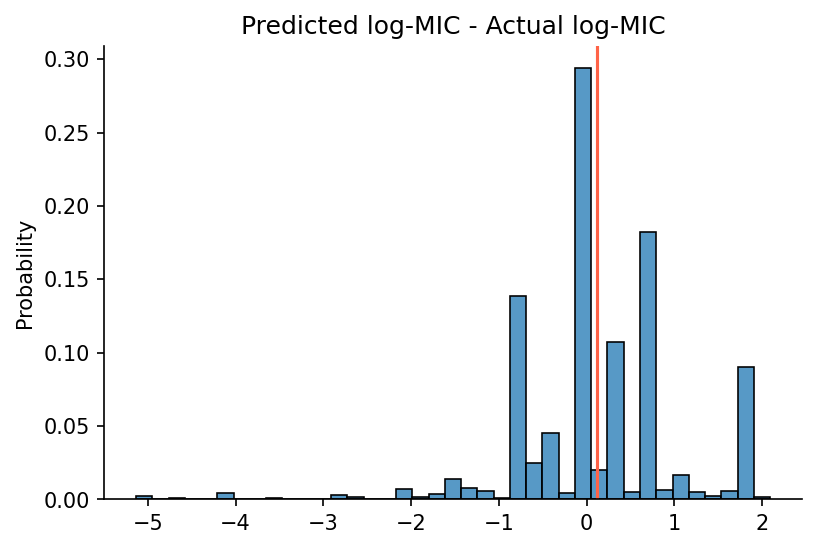

In [53]:
error_dist("20220902_moxi_gyrBA")

-0.006345104482445493 0.8100437303833713


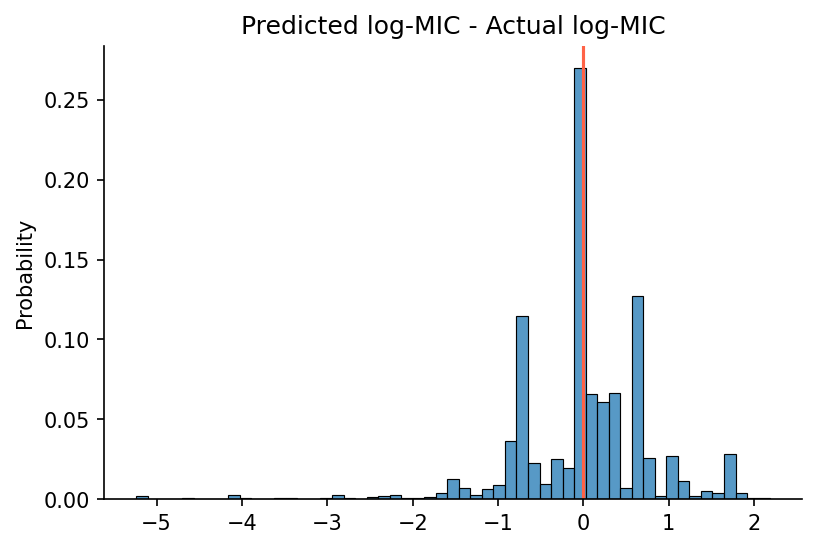

In [54]:
error_dist("20220907_moxi_12Loci")